In [ ]:
import pandas as pd
import plotly.express as px
import os
import numpy as np
import plotly.graph_objects as go
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import ParameterGrid
from torchsummary import summary

In [ ]:
!git clone https://github.com/wkzs111/phm-ieee-2012-data-challenge-dataset.git

Cloning into 'phm-ieee-2012-data-challenge-dataset'...
remote: Enumerating objects: 28426, done.
remote: Total 28426 (delta 0), reused 0 (delta 0), pack-reused 28426 (from 1)
Receiving objects: 100% (28426/28426), 483.08 MiB | 11.99 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Updating files: 100% (42744/42744), done.


In [ ]:
cam = "phm-ieee-2012-data-challenge-dataset/Learning_set/Bearing1_1"
arq = os.listdir(cam)

len(arq)

2803

## Pré-processamento dos dados

In [ ]:
lista_dados = []

for arquivo in arq:
    caminho2 = os.path.join(cam, arquivo)

    dados = np.loadtxt(caminho2, delimiter=',')
    ch1 = dados[:, 4]

    lista_dados.append(ch1)

df = pd.DataFrame(lista_dados)

In [ ]:
df

,0,1,2,3,4,5,6,7,8,9,...,2550,2551,2552,2553,2554,2555,2556,2557,2558,2559
0,-0.291,-0.474,-0.298,0.076,-0.138,0.054,0.073,0.358,-0.112,-0.423,...,-0.505,-0.156,-0.416,0.023,-0.071,-0.048,-0.414,-0.264,-0.337,-0.347
1,0.064,0.255,0.276,0.236,1.072,1.154,1.474,0.756,-0.268,-0.694,...,-0.636,-0.517,-1.202,-1.286,-0.765,-1.143,-0.331,-0.226,0.332,1.083
2,-0.858,-1.153,-0.779,-0.823,-0.273,-0.148,-0.371,-0.813,-0.498,-0.523,...,0.203,-0.505,-0.396,-1.261,-0.046,-0.205,0.113,-0.289,-0.418,-0.024
3,-1.980,-0.803,-0.389,0.121,0.676,0.331,1.173,-0.032,1.283,0.373,...,0.508,-0.283,0.725,-0.708,0.662,-0.368,0.271,0.136,-0.181,0.706
4,0.073,0.218,0.242,0.241,0.104,-0.079,0.228,0.278,-0.155,-0.363,...,-0.533,-0.432,-0.187,0.351,-0.220,-0.402,-0.528,-0.190,-0.393,-0.445
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2798,-0.650,-0.593,-0.548,-0.497,-0.055,0.368,0.298,0.497,0.192,0.315,...,-0.346,-0.191,0.057,0.192,0.098,0.230,0.059,0.034,0.109,-0.141
2799,-1.722,-1.533,-1.296,-1.091,-0.941,-0.752,-0.738,-0.508,-0.540,-0.305,...,-0.730,-0.754,-1.225,-1.202,-0.671,-1.164,-1.323,-1.063,-0.979,-0.254
2800,0.001,0.419,-0.389,-0.050,0.221,-0.234,0.150,-0.531,-0.222,0.237,...,0.932,1.654,1.179,1.911,1.358,1.246,0.272,0.790,-0.506,0.231
2801,-0.909,-1.139,-1.225,-1.360,-1.211,-1.154,-0.498,-0.276,0.123,-0.158,...,0.609,0.556,0.749,0.761,0.728,0.586,0.338,-0.027,-0.058,0.190


In [ ]:
fft = np.fft.fft(df.values, axis=1)
fft_final = np.abs(fft)
df_fft = pd.DataFrame(fft_final)

frequencias = np.fft.fftfreq(2560)
indices_positivos = np.where(frequencias >= 0)[0]

df_fft_positivo = df_fft.iloc[:, indices_positivos]
df_fft_positivo

,0,1,2,3,4,5,6,7,8,9,...,1270,1271,1272,1273,1274,1275,1276,1277,1278,1279
0,38.090,6.821463,8.337989,50.115086,5.401269,8.259583,25.092654,10.094156,10.261335,49.885725,...,5.182592,6.265519,12.437671,5.220830,2.135492,4.629714,6.041742,4.022009,5.905345,3.519564
1,4.244,22.264899,22.405028,31.132607,29.460158,29.939039,101.546854,32.977780,59.820055,308.106690,...,58.588659,6.793692,23.362651,34.997579,29.741267,22.407263,77.240795,32.267136,14.534348,28.696620
2,15.981,7.431222,7.919699,41.686266,11.065238,15.214890,50.597511,7.943716,14.658323,43.604812,...,13.528079,36.433484,7.888722,22.016729,9.101798,6.600250,17.518210,16.249905,29.681275,12.093860
3,20.900,12.122410,13.325809,23.296911,11.149181,21.668100,145.878755,18.587281,24.849786,113.235112,...,47.667768,23.640271,50.354741,16.457657,19.640478,27.211665,18.975414,26.334193,1.358459,8.104279
4,52.084,5.132519,5.872773,49.330638,1.850088,1.493728,51.749977,7.244485,13.852963,67.501924,...,3.690425,3.642687,10.082705,6.946439,3.139936,5.049305,5.539591,2.147830,1.716213,6.218434
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2798,6.265,5.425823,5.373009,42.956355,4.759280,6.482329,60.566675,11.116376,13.817458,80.847234,...,4.748886,2.554087,2.597112,11.901055,6.791078,7.593572,3.990363,4.641114,4.535067,4.032835
2799,27.683,5.811323,5.830128,24.965745,8.408156,7.896056,30.205918,13.887384,5.355726,12.999041,...,10.428934,18.084073,9.013167,9.252367,7.398620,25.346501,5.393001,13.167288,15.285011,16.646575
2800,57.545,25.991900,25.740517,32.604230,30.713731,33.180466,89.542148,50.714359,60.275730,200.635550,...,9.122655,18.630794,30.725157,19.850169,7.851171,18.544181,18.345182,19.472080,4.146981,13.565202
2801,6.746,12.758607,13.083540,21.057087,21.410221,20.671042,122.174373,5.972194,7.041471,115.050657,...,9.850385,10.911277,12.726718,7.801160,14.728093,1.397048,11.573935,24.374943,8.617119,14.741966


In [ ]:
frequencias

array([ 0.        ,  0.00039063,  0.00078125, ..., -0.00117188,
       -0.00078125, -0.00039063])

In [ ]:
fft[0]

array([-38.09      +0.j        ,  -6.73946599+1.05449186j,
        -8.3044804 +0.74677247j, ..., -49.99223794+3.50684527j,
        -8.3044804 -0.74677247j,  -6.73946599-1.05449186j])

In [ ]:
train_data = torch.tensor(df_fft_positivo.values[:int(0.2 * len(df_fft_positivo))], dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_data, train_data), batch_size=32, shuffle=True)

In [ ]:
len(train_data), len(train_loader)

(560, 18)

## Criação da rede Autoencoder com avaliação MSE

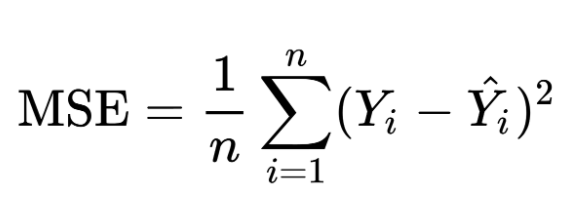

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()


        self.encoder = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(True),
            nn.Linear(512, 256),
            nn.ReLU(True),
            nn.Linear(256, 10)
        )
        self.decoder = nn.Sequential(
            nn.Linear(10, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1280)
        )

    def forward(self, x):
        encoder = self.encoder(x)
        decoder = self.decoder(encoder)
        return decoder

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr= 0.001)

In [ ]:
summary(model, (1280,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 512]         655,872
              ReLU-2                  [-1, 512]               0
            Linear-3                  [-1, 256]         131,328
              ReLU-4                  [-1, 256]               0
            Linear-5                   [-1, 10]           2,570
            Linear-6                  [-1, 256]           2,816
              ReLU-7                  [-1, 256]               0
            Linear-8                  [-1, 512]         131,584
              ReLU-9                  [-1, 512]               0
           Linear-10                 [-1, 1280]         656,640
Total params: 1,580,810
Trainable params: 1,580,810
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 6.03
Estimat

## Treinamento da rede com 20% dos dados iniciais e 50 épocas

In [ ]:
num_epochs = 500

model.train()
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch in train_loader:
        inputs, _ = batch
        inputs = inputs.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    print(f"Época: [{epoch+1} / {num_epochs}], Média Loss: {total_loss/len(train_loader):.6f}")

Época: [1 / 500], Média Loss: 1933.269495
Época: [2 / 500], Média Loss: 1061.585217
Época: [3 / 500], Média Loss: 823.828357
Época: [4 / 500], Média Loss: 779.607043
Época: [5 / 500], Média Loss: 706.113513
Época: [6 / 500], Média Loss: 680.862292
Época: [7 / 500], Média Loss: 688.414600
Época: [8 / 500], Média Loss: 715.793042
Época: [9 / 500], Média Loss: 698.694214
Época: [10 / 500], Média Loss: 664.022992
Época: [11 / 500], Média Loss: 657.110876
Época: [12 / 500], Média Loss: 652.504065
Época: [13 / 500], Média Loss: 721.595129
Época: [14 / 500], Média Loss: 680.565350
Época: [15 / 500], Média Loss: 670.696472
Época: [16 / 500], Média Loss: 662.927979
Época: [17 / 500], Média Loss: 749.754297
Época: [18 / 500], Média Loss: 662.314471
Época: [19 / 500], Média Loss: 653.045715
Época: [20 / 500], Média Loss: 617.504004
Época: [21 / 500], Média Loss: 556.619110
Época: [22 / 500], Média Loss: 533.133423
Época: [23 / 500], Média Loss: 519.733948
Época: [24 / 500], Média Loss: 517.791223

## Aplicando encoder ao dataset completo

In [ ]:
dados_tensor = torch.tensor(df_fft_positivo.values, dtype=torch.float32).to(device)
dados_encoded = model.encoder(dados_tensor).cpu().detach().numpy()
encoded_df = pd.DataFrame(dados_encoded)

In [ ]:
encoded_df

,0,1,2,3,4,5,6,7,8,9
0,-1.981417,35.889194,-64.458572,42.298279,-88.698120,-80.905891,6.022383,12.759083,112.869316,43.361839
1,95.644981,177.558899,-202.449127,467.029510,-557.966003,259.039276,72.625206,218.045990,271.187225,-20.713352
2,59.226349,16.205774,-103.900047,94.950958,-206.881989,-135.451675,41.203209,19.282022,178.132950,45.036835
3,393.460571,92.724518,-382.044159,615.046692,-541.153259,186.610123,-88.242111,-241.780716,119.084755,15.905750
4,-10.402274,44.410309,-74.659691,62.299606,-88.571335,-93.469994,18.903101,12.059789,128.134079,48.716892
...,...,...,...,...,...,...,...,...,...,...
2798,-14.315633,48.661884,-67.836143,48.904392,-85.291458,-84.144936,12.832024,16.101965,106.347084,42.364872
2799,59.992424,27.765263,-127.948242,222.569824,-245.396606,-151.688904,136.604187,18.813503,262.639038,53.916851
2800,28.696466,-51.488579,-150.090500,251.349197,-298.880432,-82.156769,136.795471,62.232876,250.598404,75.545212
2801,6.358621,22.997181,-155.482529,198.206268,-256.419495,-70.018761,71.629333,41.849545,229.967758,80.873192


como as ativações dos 10 neurônios da camada comprimida do Autoencoder variam ao longo do experimento.

conforme o rolamento sofre degradação, os padrões das medições mudam.

In [ ]:
fig = go.Figure()
for i in range(10):
    fig.add_trace(go.Scatter(y=encoded_df[i], mode='lines', name=f'Neurônio {i+1}'))

fig.update_layout(title="Variação das predições do encoder ao longo do experimento",
                  xaxis_title="Medição",
                  template="plotly_white")
fig.show()

#### **Possíveis análises**

1. Se algumas curvas apresentam um comportamento sistemático ao longo do tempo, pode indicar padrões que o Autoencoder conseguiu captar na degradação do rolamento.

2. Se houver variações bruscas nas ativações, pode significar mudanças significativas nas características de vibração, sugerindo um ponto de falha iminente no equipamento.

3. Se algumas curvas são semelhantes ou se movem juntas, pode indicar que determinados neurônios aprenderam representações semelhantes.

In [ ]:
encoded_df.iloc[73]

,73
0,-322.643799
1,2908.419678
2,-1078.085449
3,2026.145996
4,1859.194336
5,-460.632111
6,-71.864113
7,72.731812
8,-86.202339
9,-470.152924


## Testando com outra rede Autoencoder

In [ ]:
class Autoencoder2(nn.Module):
    def __init__(self):
        super(Autoencoder2, self).__init__()


        self.encoder = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(True),
            nn.Linear(512, 256),
            nn.ReLU(True),
            nn.Linear(256, 128),
            nn.ReLU(True),
            nn.Linear(128, 64),
            nn.ReLU(True),
            nn.Linear(64, 10)
        )
        self.decoder = nn.Sequential(
            nn.Linear(10, 64),
            nn.ReLU(True),
            nn.Linear(64, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1280)
        )

    def forward(self, x):
        encoder = self.encoder(x)
        decoder = self.decoder(encoder)
        return decoder

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2 = Autoencoder2().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model2.parameters(), lr= 0.0001)

In [ ]:
num_epochs = 500

model2.train()
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch in train_loader:
        inputs, _ = batch
        inputs = inputs.to(device)
        optimizer.zero_grad()
        outputs = model2(inputs)
        loss = criterion(outputs, inputs)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    print(f"Época: [{epoch+1} / {num_epochs}], Média Loss: {total_loss/len(train_loader):.6f}")

Época: [1 / 500], Média Loss: 2434.580363
Época: [2 / 500], Média Loss: 2454.028117
Época: [3 / 500], Média Loss: 1704.505388
Época: [4 / 500], Média Loss: 1126.190901
Época: [5 / 500], Média Loss: 834.940338
Época: [6 / 500], Média Loss: 744.283147
Época: [7 / 500], Média Loss: 705.501511
Época: [8 / 500], Média Loss: 694.180678
Época: [9 / 500], Média Loss: 689.918627
Época: [10 / 500], Média Loss: 724.571235
Época: [11 / 500], Média Loss: 696.193234
Época: [12 / 500], Média Loss: 684.883852
Época: [13 / 500], Média Loss: 686.833208
Época: [14 / 500], Média Loss: 681.852698
Época: [15 / 500], Média Loss: 688.620336
Época: [16 / 500], Média Loss: 693.079059
Época: [17 / 500], Média Loss: 681.501411
Época: [18 / 500], Média Loss: 685.379591
Época: [19 / 500], Média Loss: 681.947410
Época: [20 / 500], Média Loss: 687.095551
Época: [21 / 500], Média Loss: 683.116906
Época: [22 / 500], Média Loss: 688.414552
Época: [23 / 500], Média Loss: 689.351793
Época: [24 / 500], Média Loss: 685.0000

In [ ]:
dados_encoded2 = model2.encoder(dados_tensor).cpu().detach().numpy()
encoded_df2 = pd.DataFrame(dados_encoded2)

In [ ]:
fig = go.Figure()
for i in range(10):
    fig.add_trace(go.Scatter(y=encoded_df2[i], mode='lines', name=f'Neurônio {i+1}'))

fig.update_layout(title="Variação das predições do encoder ao longo do experimento",
                  xaxis_title="Medição",
                  template="plotly_white")
fig.show()

## Aplicando GridSearch para busca de melhores hiperparâmetros

In [ ]:
param_grid = {
    "layer1": [256, 512, 1024],
    "layer2": [128, 256, 512],
    "lr": [0.0001, 0.001, 0.003, 0.005],
    "batch_size": [32, 64, 128]
}

best_loss = float("inf")
best_params = None

In [ ]:
def train_autoencoder(params):
    global best_loss, best_params
    train_loader = DataLoader(TensorDataset(train_data, train_data), batch_size=params['batch_size'], shuffle=True)

    class Autoencoder3(nn.Module):
        def __init__(self):
            super(Autoencoder3, self).__init__()


            self.encoder = nn.Sequential(
                nn.Linear(1280, params['layer1']),
                nn.ReLU(),
                nn.Linear(params['layer1'], params['layer2']),
                nn.ReLU(),
                nn.Linear(params['layer2'], 10)
            )
            self.decoder = nn.Sequential(
                nn.Linear(10, params['layer2']),
                nn.ReLU(),
                nn.Linear(params['layer2'], params['layer1']),
                nn.ReLU(),
                nn.Linear(params['layer1'], 1280)
            )

        def forward(self, x):
            encoder = self.encoder(x)
            decoder = self.decoder(encoder)
            return decoder

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = Autoencoder3().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=params['lr'])
    num_epochs = 50
    total_loss = 0.0

    model.train()
    for epoch in range(num_epochs):
        epoca_loss = 0.0
        for batch in train_loader:
            inputs, _ = batch
            inputs = inputs.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            epoca_loss += loss.item()
            loss.backward()
            optimizer.step()
        total_loss = epoca_loss / len(train_loader)

    if total_loss < best_loss:
        best_loss = total_loss
        best_params = params.copy()

    return total_loss

In [ ]:
for params in ParameterGrid(param_grid):
    loss = train_autoencoder(params)
    print(f"teste com {params} --- Loss: {loss:.7f}")

print("melhores hiperparâmetros:", best_params)

teste com {'batch_size': 32, 'layer1': 256, 'layer2': 128, 'lr': 0.0001} --- Loss: 477.6882341
teste com {'batch_size': 32, 'layer1': 256, 'layer2': 128, 'lr': 0.001} --- Loss: 537.2668932
teste com {'batch_size': 32, 'layer1': 256, 'layer2': 128, 'lr': 0.003} --- Loss: 495.8536903
teste com {'batch_size': 32, 'layer1': 256, 'layer2': 128, 'lr': 0.005} --- Loss: 562.7548760
teste com {'batch_size': 32, 'layer1': 256, 'layer2': 256, 'lr': 0.0001} --- Loss: 449.4761539
teste com {'batch_size': 32, 'layer1': 256, 'layer2': 256, 'lr': 0.001} --- Loss: 431.3835305
teste com {'batch_size': 32, 'layer1': 256, 'layer2': 256, 'lr': 0.003} --- Loss: 635.1723412
teste com {'batch_size': 32, 'layer1': 256, 'layer2': 256, 'lr': 0.005} --- Loss: 687.9045715
teste com {'batch_size': 32, 'layer1': 256, 'layer2': 512, 'lr': 0.0001} --- Loss: 463.8751653
teste com {'batch_size': 32, 'layer1': 256, 'layer2': 512, 'lr': 0.001} --- Loss: 479.8329824
teste com {'batch_size': 32, 'layer1': 256, 'layer2': 512

In [ ]:
train_loader = DataLoader(TensorDataset(train_data, train_data), batch_size=64, shuffle=True)

class Autoencoder_best(nn.Module):
    def __init__(self):
        super(Autoencoder_best, self).__init__()


        self.encoder = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(True),
            nn.Linear(512, 128),
            nn.ReLU(True),
            nn.Linear(128, 10)
        )
        self.decoder = nn.Sequential(
            nn.Linear(10, 128),
            nn.ReLU(True),
            nn.Linear(128, 512),
            nn.ReLU(True),
            nn.Linear(512, 1280)
        )

    def forward(self, x):
        encoder = self.encoder(x)
        decoder = self.decoder(encoder)
        return decoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model3 = Autoencoder_best().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model3.parameters(), lr= 0.001)

num_epochs = 500

model3.train()
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch in train_loader:
        inputs, _ = batch
        inputs = inputs.to(device)
        optimizer.zero_grad()
        outputs = model3(inputs)
        loss = criterion(outputs, inputs)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    print(f"Época: [{epoch+1} / {num_epochs}], Média Loss: {total_loss/len(train_loader):.6f}")

Época: [1 / 500], Média Loss: 1701.063246
Época: [2 / 500], Média Loss: 864.026991
Época: [3 / 500], Média Loss: 734.893856
Época: [4 / 500], Média Loss: 734.872423
Época: [5 / 500], Média Loss: 708.757046
Época: [6 / 500], Média Loss: 679.646006
Época: [7 / 500], Média Loss: 650.772556
Época: [8 / 500], Média Loss: 654.329827
Época: [9 / 500], Média Loss: 620.062653
Época: [10 / 500], Média Loss: 577.093631
Época: [11 / 500], Média Loss: 549.614109
Época: [12 / 500], Média Loss: 545.161028
Época: [13 / 500], Média Loss: 525.476318
Época: [14 / 500], Média Loss: 532.839961
Época: [15 / 500], Média Loss: 508.614322
Época: [16 / 500], Média Loss: 506.463464
Época: [17 / 500], Média Loss: 509.301283
Época: [18 / 500], Média Loss: 503.571411
Época: [19 / 500], Média Loss: 492.017107
Época: [20 / 500], Média Loss: 463.750580
Época: [21 / 500], Média Loss: 459.718048
Época: [22 / 500], Média Loss: 443.149268
Época: [23 / 500], Média Loss: 439.152744
Época: [24 / 500], Média Loss: 427.978858


In [ ]:
dados_encoded3 = model3.encoder(dados_tensor).cpu().detach().numpy()
encoded_df3 = pd.DataFrame(dados_encoded3)

encoded_df3

,0,1,2,3,4,5,6,7,8,9
0,-36.415337,-86.628677,39.117271,-23.760559,44.113464,29.405220,-10.766541,38.275620,103.316536,-124.439667
1,-93.066292,-346.815460,-129.488388,279.504333,636.892334,323.023224,-438.239197,126.037926,339.549927,-224.516510
2,-29.732307,-198.768082,7.518871,11.876699,78.575142,-10.710151,-46.127846,82.556808,219.477081,-151.313492
3,90.596413,-111.518547,-130.897812,480.925659,819.108643,101.826363,-456.457367,318.934357,280.848541,139.204819
4,-12.613447,-89.089577,39.007172,-25.556717,68.580933,58.591431,-14.214870,50.468754,119.661972,-136.521347
...,...,...,...,...,...,...,...,...,...,...
2798,-11.804248,-82.928406,32.188236,-16.789410,58.553764,67.990227,-17.889456,32.667683,94.010628,-122.909859
2799,61.902161,-230.312912,44.567772,30.383970,227.040833,47.532887,-109.227295,105.086052,306.450012,-233.581207
2800,107.487358,-193.497665,154.997009,-95.846603,211.508209,-35.051666,-103.947655,139.645859,348.470367,-144.533554
2801,-29.956554,-174.528320,79.158112,-38.162178,240.929062,107.816528,-105.459000,97.126534,279.137085,-188.253525


In [ ]:
fig = go.Figure()
for i in range(10):
    fig.add_trace(go.Scatter(y=encoded_df3[i], mode='lines', name=f'Neurônio {i+1}'))

fig.update_layout(title="Variação das predições do encoder ao longo do experimento",
                  xaxis_title="Medição",
                  template="plotly_white")
fig.show()